# Retraining after a policy censors labels — results

A policy creates two problems at once: old models decay as the outcome process drifts, and the labels that remain observable are selected by the policy itself. This notebook builds the argument in that order, then compares every retraining method.

**Terminology.** AIPW means **Asymmetric IPW** here. The asymmetric family weights flagged holdout observations by `alpha / holdout_pct`; pooled validation chooses between dropping (`alpha = holdout_pct`) and pure IPW (`alpha = 1`).

Three mechanisms form the causal spine: **global drift** makes old models stale; **regional shift** creates policy-hidden information; and **regional drift** changes that hidden signal over time. Trigger rate, holdout size and base rate are operating conditions that determine how much information each method receives.

Error bars are two-sided 95% t intervals across five paired population draws.

In [0]:
import json
import os

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
import numpy as np
import pandas as pd
from scipy.stats import t

try:
    _path = dbutils.notebook.entry_point.getDbutils().notebook().getContext().notebookPath().get()
    HERE = "/Workspace" + "/".join(_path.split("/")[:-1])
except NameError:
    HERE = os.getcwd()

RESULTS = os.path.join(HERE, "sim-results")
FIGURES = os.path.join(HERE, "sim-figures")
os.makedirs(FIGURES, exist_ok=True)

required = [
    "scenario_definitions", "method_raw", "method_summary", "endpoint_summary",
    "asymmetric_summary", "drift_trajectory",
]
tables = {name: pd.read_csv(os.path.join(RESULTS, f"{name}.csv")) for name in required}
progress = json.load(open(os.path.join(RESULTS, "progress.json")))
drift_progress = json.load(open(os.path.join(RESULTS, "drift_progress.json")))
if any(value["stage"] != "complete" or value["errors"]
       for value in (progress, drift_progress)):
    raise RuntimeError(f"01_simulation is incomplete: {progress}, {drift_progress}")

scenarios = tables["scenario_definitions"]
raw = tables["method_raw"]
methods = tables["method_summary"]
endpoints = tables["endpoint_summary"]
asymmetric = tables["asymmetric_summary"]
drift = tables["drift_trajectory"]

METHOD_ORDER = [
    "R5_asymmetric", "R4_ipw_pure", "R3_drop_unweighted", "R2_unflagged_only",
    "R1_holdout_only", "R6_no_retrain", "R7_incremental",
]
METHOD_LABELS = {
    "R0_benchmark": "Oracle", "R1_holdout_only": "Holdout only",
    "R2_unflagged_only": "No holdout", "R3_drop_unweighted": "Dropping",
    "R4_ipw_pure": "IPW", "R5_asymmetric": "Asymmetric IPW",
    "R6_no_retrain": "No retraining", "R7_incremental": "Incremental",
}
SHORT_LABELS = {**METHOD_LABELS, "R5_asymmetric": "Asym. IPW",
                "R6_no_retrain": "No retrain"}
SCENARIO_ORDER = scenarios.scenario_id.tolist()
SCENARIO_LABELS = {
    "no_shift": "No regional signal",
    "low_shift": "Weak regional signal + drift",
    "reference": "Strong regional signal",
    "reference_drift": "Strong regional signal + drift",
    "high_trigger_low_holdout": "No regional signal · 12% trigger · 2% holdout",
    "low_base_high_holdout": "Strong regional signal · 0.1% base · 20% holdout",
}
SCENARIO_SHORT = {
    "no_shift": "No regional signal", "low_shift": "Weak signal + drift",
    "reference": "Strong signal", "reference_drift": "Strong signal + drift",
    "high_trigger_low_holdout": "High trigger / low holdout",
    "low_base_high_holdout": "Low base / high holdout",
}

# Colorblind-safe focal colors; alternatives deliberately recede.
INK = "#182230"
MUTED = "#657286"
GRID = "#DCE2EA"
ORACLE = "#343C48"
COLORS = {
    "R5_asymmetric": "#6F4E9C",
    "R4_ipw_pure": "#0072B2",
    "R3_drop_unweighted": "#D55E00",
    "R2_unflagged_only": "#A8B0BC",
    "R1_holdout_only": "#8793A3",
    "R6_no_retrain": "#C2C7CE",
    "R7_incremental": "#6F7A89",
}
HOLDOUT_FOCUS = "#008B72"
OBSERVED = "#D8903D"
RANDOMIZED = "#0072B2"
FULL_POPULATION = "#3D4654"

# Three deliberate scale tiers. Separate endpoint exports declare their tighter scale in the title.
SCALE_BROAD = (84.0, 100.5)
SCALE_MAIN = (88.0, 100.5)
SCALE_ENDPOINT = (94.0, 100.6)

plt.rcParams.update({
    "figure.dpi": 125,
    "savefig.dpi": 200,
    "font.family": "DejaVu Sans",
    "font.size": 10.5,
    "text.color": INK,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "axes.titlesize": 14,
    "axes.titleweight": 500,
    "axes.titlelocation": "left",
    "axes.labelsize": 11,
    "xtick.color": MUTED,
    "ytick.color": INK,
    "legend.frameon": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
})


def save(name):
    path = os.path.join(FIGURES, name)
    plt.savefig(path, bbox_inches="tight", facecolor="white", pad_inches=0.12)
    print(os.path.relpath(path, HERE))


def mean_ci(values):
    values = pd.Series(values).dropna()
    mean = values.mean()
    if len(values) < 2 or values.std(ddof=1) == 0:
        return mean, 0.0
    half = t.ppf(0.975, len(values) - 1) * values.std(ddof=1) / np.sqrt(len(values))
    return mean, half


def estimates(frame, groups, value):
    rows = []
    for keys, group in frame.groupby(groups, sort=False):
        keys = keys if isinstance(keys, tuple) else (keys,)
        mean, half = mean_ci(group[value])
        rows.append(dict(zip(groups, keys)) | {"mean": mean, "half": half})
    return pd.DataFrame(rows)


def clean_axis(ax, grid="x", step=None):
    ax.set_axisbelow(True)
    ax.grid(axis=grid, color=GRID, linewidth=0.8, alpha=0.8)
    ax.tick_params(length=0, pad=6)
    if step is not None:
        (ax.xaxis if grid == "x" else ax.yaxis).set_major_locator(MultipleLocator(step))


def oracle_ceiling(ax, label=False):
    ax.axvline(100, color=ORACLE, lw=1.1, ls=(0, (3, 3)), zorder=1)
    if label:
        ax.text(100, 1.015, "oracle ceiling", transform=ax.get_xaxis_transform(),
                ha="right", va="bottom", color=MUTED, fontsize=9)


def period_legend():
    return [
        Patch(facecolor="#8E99A8", alpha=0.38, label="Early · M1"),
        Patch(facecolor="#8E99A8", alpha=0.96, label="Late · M12"),
    ]


def method_legend(method_ids):
    return [Patch(facecolor=COLORS[method], label=METHOD_LABELS[method])
            for method in method_ids]


def label_bar(ax, value, y, xlim, text=None, color=INK, fontsize=9):
    span = xlim[1] - xlim[0]
    if value > xlim[1] - 0.07 * span:
        x, ha = value - 0.012 * span, "right"
    else:
        x, ha = value + 0.012 * span, "left"
    ax.text(x, y, text or f"{value:.1f}", va="center", ha=ha,
            color=color, fontsize=fontsize, fontweight=500)


oracle = (raw[raw.method == "R0_benchmark"]
          [["scenario_id", "period", "seed", "test_pAUC"]]
          .rename(columns={"test_pAUC": "oracle_pAUC"}))
relative = raw.merge(oracle, on=["scenario_id", "period", "seed"], how="left")
relative["pct_oracle"] = 100 * relative.test_pAUC / relative.oracle_pAUC
all_estimates = estimates(relative, ["scenario_id", "period", "method"], "pct_oracle")


def method_bars(ax, panel, method_ids, xlim, title, show_errors=True,
                show_labels=True, ceiling_label=False):
    cell = panel.set_index("method").reindex(method_ids)
    y = np.arange(len(method_ids))
    left = xlim[0]
    widths = cell["mean"].values - left
    errors = cell["half"].values if show_errors else None
    ax.barh(y, widths, left=left, xerr=errors, height=0.62,
            color=[COLORS[method] for method in method_ids],
            error_kw={"ecolor": INK, "elinewidth": 1.1, "capsize": 2.5, "capthick": 1.1},
            zorder=3)
    ax.set_yticks(y, [METHOD_LABELS[method] for method in method_ids])
    ax.set_ylim(len(method_ids) - 0.5, -0.5)
    ax.set_xlim(*xlim)
    ax.set_title(title, pad=12)
    ax.set_xlabel("Test pAUC · % of oracle")
    clean_axis(ax, "x", 2)
    oracle_ceiling(ax, ceiling_label)
    if show_labels:
        focus = {"R5_asymmetric", "R4_ipw_pure", "R3_drop_unweighted"}
        for row, (method, values) in enumerate(cell.iterrows()):
            value = values["mean"]
            half = values["half"] if show_errors else 0
            span = xlim[1] - xlim[0]
            if method in focus:
                x, ha, color, weight = value - half - 0.018 * span, "right", "white", 700
            elif value + half + 0.07 * span < xlim[1]:
                x, ha = value + half + 0.015 * span, "left"
                color, weight = INK, 600
            else:
                x, ha = value - half - 0.015 * span, "right"
                color, weight = INK, 600
            ax.text(x, row, f"{value:.1f}", va="center", ha=ha,
                    color=color, fontsize=10.5, fontweight=weight)


print(json.dumps({"main": progress, "drift": drift_progress}, indent=2))

{
  "main": {
    "completed": 60,
    "elapsed_minutes": 47.16970172723134,
    "errors": 0,
    "stage": "complete",
    "total": 60
  },
  "drift": {
    "completed": 20,
    "elapsed_minutes": 8.161759773890177,
    "errors": 0,
    "stage": "complete",
    "total": 20
  }
}


## Simulation parameters and scenarios

### Mechanisms and operating conditions

| Parameter | Meaning | Reference value |
|---|---|---:|
| `region_shift` | Strength of the extra outcome signal in the 15% high-amount region. Zero means that region has no distinct outcome mechanism. | 1.50 |
| `drift_per_month` | Monthly rotation of the global outcome direction, expressed as a fraction of a 90° turn. `0.02` is 1.8° per month. | 0.02 |
| `region_drift_per_month` | Monthly rotation of the regional outcome direction on the same scale. | 0 |
| `trigger_rate` | Fraction of observations flagged by the policy each month. | 6% |
| `holdout_pct` | Fraction of flagged decisions randomized into holdout, preserving their labels. | 5% |
| `base_rate` | Event prevalence, calibrated independently each month. | 1% |

### Simulated scenarios

| Scenario | Global drift | Regional shift | Regional drift | Trigger | Holdout | Base rate |
|---|---:|---:|---:|---:|---:|---:|
| No regional signal | 0.02 | 0 | 0 | 6% | 5% | 1% |
| Weak regional signal + drift | 0.02 | 0.25 | 0.02 | 6% | 5% | 1% |
| Strong regional signal | 0.02 | 1.50 | 0 | 6% | 5% | 1% |
| Strong regional signal + drift | 0.02 | 1.50 | 0.02 | 6% | 5% | 1% |
| No regional signal; high trigger; low holdout | 0.02 | 0 | 0 | 12% | 2% | 1% |
| Strong regional signal; low base; high holdout | 0.02 | 1.50 | 0 | 6% | 20% | 0.1% |

### Parameters held fixed

| Parameter | Meaning | Value |
|---|---|---:|
| Rows per month | Population available in each training month | 420,000 |
| Pre-launch history | Fully observed history before policy launch | 6 months |
| Training window | Rolling window used by retrained methods | 6 months |
| Validation / test size | Independent observations in each evaluation month | 420,000 / 420,000 |
| Features / informative features | Gaussian predictors and predictors entering global risk | 100 / 8 |
| Risk strength | Scale of the outcome log-odds signal | 1.8 |
| Regional share | High-amount population receiving the regional outcome term | 15% |
| Policy noise | Noise in the policy's risk estimate; larger is less precise | 1.8 |
| Amount weight | Share of the policy score attributable to standardized log amount | 0.7 |
| Negative-to-positive ratio | Negative undersampling ratio after filtering and weighting | 30:1 |
| Replicates | Paired population draws per scenario-period | 5 |
| Endpoint timeline | Validation at M=1 or M=12; test in the following month | M / M+1 |
| Metric | Normalized partial AUC through 20% FPR; random = 0.1, perfect = 1 | pAUC@20% |

**Scale convention.** Broad six-scenario views use 84–100.5% of oracle; the `reference drift`
scenario uses 88–100.5%; endpoint comparisons use 94–100.6%. Any tighter average-performance
export is explicitly labeled as zoomed.

## 1. Why retrain? Drift makes a fixed model stale

The model is fitted once on all six pre-launch months. Regional shift is off, so the only
changing mechanism is global drift. The middle line is the drift configuration used in the
remainder of the study; the redundant intermediate rate is omitted.

sim-figures/fig01_no_retrain_drift.png


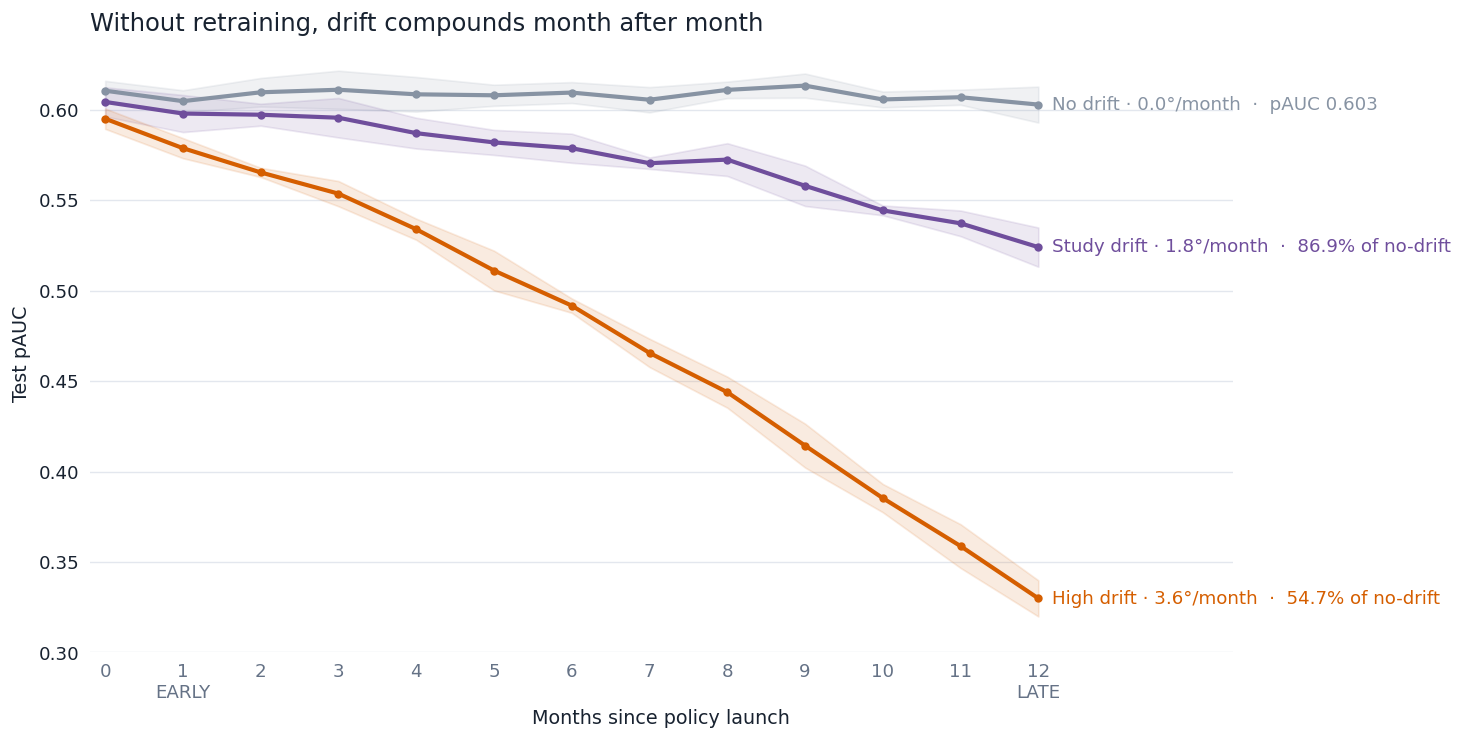

In [0]:
drift_rates = [0.00, 0.02, 0.04]
drift_summary = estimates(
    drift[drift.drift_per_month.isin(drift_rates)], ["drift_per_month", "month"], "pAUC")
drift_colors = {0.00: "#8793A3", 0.02: "#6F4E9C", 0.04: "#D55E00"}
drift_labels = {
    0.00: "No drift · 0.0°/month",
    0.02: "Study drift · 1.8°/month",
    0.04: "High drift · 3.6°/month",
}
month12 = (drift_summary[drift_summary.month == 12]
           .set_index("drift_per_month")["mean"])
no_drift_month12 = month12.loc[0.00]

fig, ax = plt.subplots(figsize=(11.8, 6.2))
for rate in drift_rates:
    line = drift_summary[drift_summary.drift_per_month == rate].sort_values("month")
    color = drift_colors[rate]
    ax.plot(line.month, line["mean"], marker="o", ms=3.8, lw=2.4,
            color=color, zorder=3)
    ax.fill_between(line.month, line["mean"] - line["half"],
                    line["mean"] + line["half"], color=color, alpha=0.12)
    last = line.iloc[-1]
    endpoint = (f"pAUC {last['mean']:.3f}" if rate == 0
                else f"{100 * last['mean'] / no_drift_month12:.1f}% of no-drift")
    ax.text(12.18, last["mean"], f"{drift_labels[rate]}  ·  {endpoint}",
            va="center", color=color, fontsize=10.5, fontweight=500)
ax.set_xlim(-0.2, 14.5)
ax.set_ylim(0.30, 0.63)
ax.set_xticks(range(13), ["0", "1\nEARLY", "2", "3", "4", "5", "6", "7",
                           "8", "9", "10", "11", "12\nLATE"])
ax.set_xlabel("Months since policy launch")
ax.set_ylabel("Test pAUC")
ax.set_title("Without retraining, drift compounds month after month", pad=14)
clean_axis(ax, "y", 0.05)
save("fig01_no_retrain_drift.png")
plt.show()

The rest of the study fixes global drift at `0.02` per month—the purple trajectory. This is
strong enough to make stale models visibly deteriorate without making retraining hopeless.

## 2. Why keep a randomized holdout? The observable cohort gives a different answer

We focus on the two strong-regional-signal scenarios and average over early and late
endpoints. Grouped bars compare the metric available from policy-selected observable labels,
the randomized audit cohort, and an independent full-population test set. The last is the
oracle measurement surface; neither displayed method uses it for fitting or selection.

sim-figures/fig02_metric_bias.png


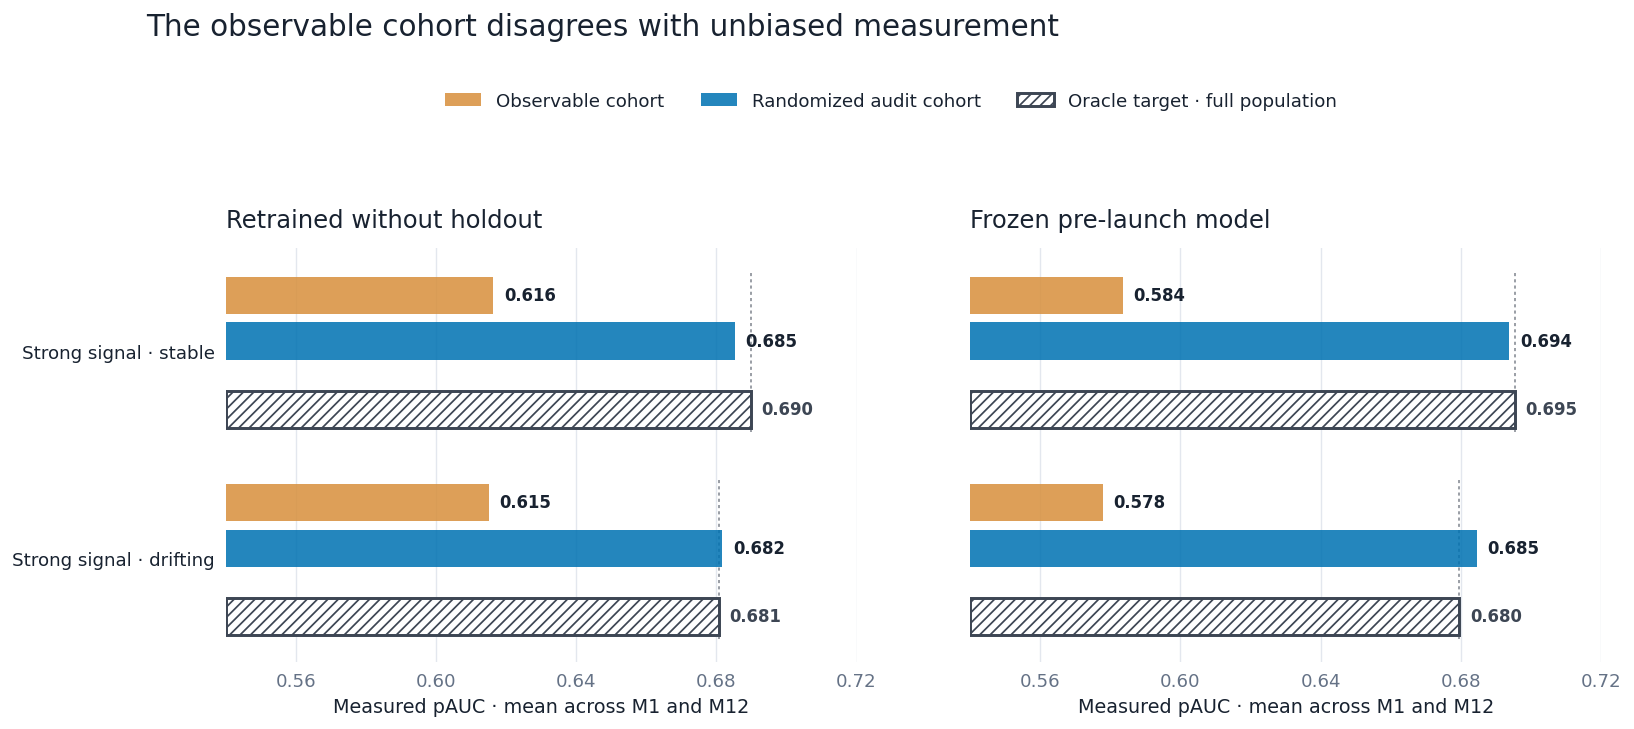

In [0]:
bias_methods = ["R2_unflagged_only", "R6_no_retrain"]
bias_scenarios = ["reference", "reference_drift"]
bias = (raw[raw.method.isin(bias_methods) & raw.scenario_id.isin(bias_scenarios)]
        .groupby(["method", "scenario_id"], as_index=False)
        .agg(observed=("observed_valid_pAUC", "mean"),
             randomized=("holdout_valid_pAUC", "mean"),
             oracle=("test_pAUC", "mean")))

fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.1), sharex=True, sharey=True)
for ax, method in zip(axes, bias_methods):
    cell = bias[bias.method == method].set_index("scenario_id").reindex(bias_scenarios)
    y = np.arange(len(bias_scenarios))
    bar_specs = [
        ("observed", "Observable cohort", OBSERVED, -0.27),
        ("randomized", "Randomized audit cohort", RANDOMIZED, -0.05),
        ("oracle", "Oracle target · full population", "white", 0.28),
    ]
    for column, label, color, offset in bar_specs:
        positions = y + offset
        values = cell[column].to_numpy()
        is_oracle = column == "oracle"
        ax.barh(
            positions, values - 0.54, left=0.54, height=0.18,
            color=color, alpha=1.0 if is_oracle else 0.86,
            edgecolor=FULL_POPULATION if is_oracle else "none",
            linewidth=1.7 if is_oracle else 0,
            hatch="////" if is_oracle else None,
            zorder=4 if is_oracle else 3, label=label,
        )
        for position, value in zip(positions, values):
            ax.text(value + 0.003, position, f"{value:.3f}", va="center",
                    color=FULL_POPULATION if is_oracle else INK,
                    fontsize=9.5, fontweight=700 if is_oracle else 600)
    for row, value in enumerate(cell["oracle"].to_numpy()):
        ax.vlines(value, row - 0.38, row + 0.39, color=FULL_POPULATION,
                  lw=0.9, ls=(0, (2, 2)), alpha=0.65, zorder=2)
    ax.set_yticks(y, ["Strong signal · stable", "Strong signal · drifting"])
    ax.set_ylim(len(bias_scenarios) - 0.5, -0.5)
    ax.set_xlim(0.54, 0.72)
    ax.set_xlabel("Measured pAUC · mean across M1 and M12")
    ax.set_title("Retrained without holdout" if method == "R2_unflagged_only"
                 else "Frozen pre-launch model", pad=12)
    clean_axis(ax, "x", 0.04)
fig.legend(handles=[
    Patch(facecolor=OBSERVED, alpha=0.86, label="Observable cohort"),
    Patch(facecolor=RANDOMIZED, alpha=0.86, label="Randomized audit cohort"),
    Patch(facecolor="white", edgecolor=FULL_POPULATION, linewidth=1.7,
          hatch="////", label="Oracle target · full population"),
], loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.03))
fig.suptitle("The observable cohort disagrees with unbiased measurement",
             x=0.08, ha="left", y=1.13, fontsize=17, fontweight=500)
fig.subplots_adjust(top=0.76, wspace=0.18)
save("fig02_metric_bias.png")
plt.show()

The randomized holdout closely tracks the independent full population, while the observable
cohort does not. The holdout is therefore not only training data: it is the unbiased
measurement surface used to decide whether retraining is actually improving the model.

## 3. Holdout-only already beats doing nothing in the long term

In the strong-regional-signal + regional-drift scenario, holdout-only training sacrifices
performance early because its sample is small. A year later it overtakes both alternatives:
the no-holdout model trains on selected labels, while the unretrained model has become stale.

sim-figures/fig03_holdout_durability.png


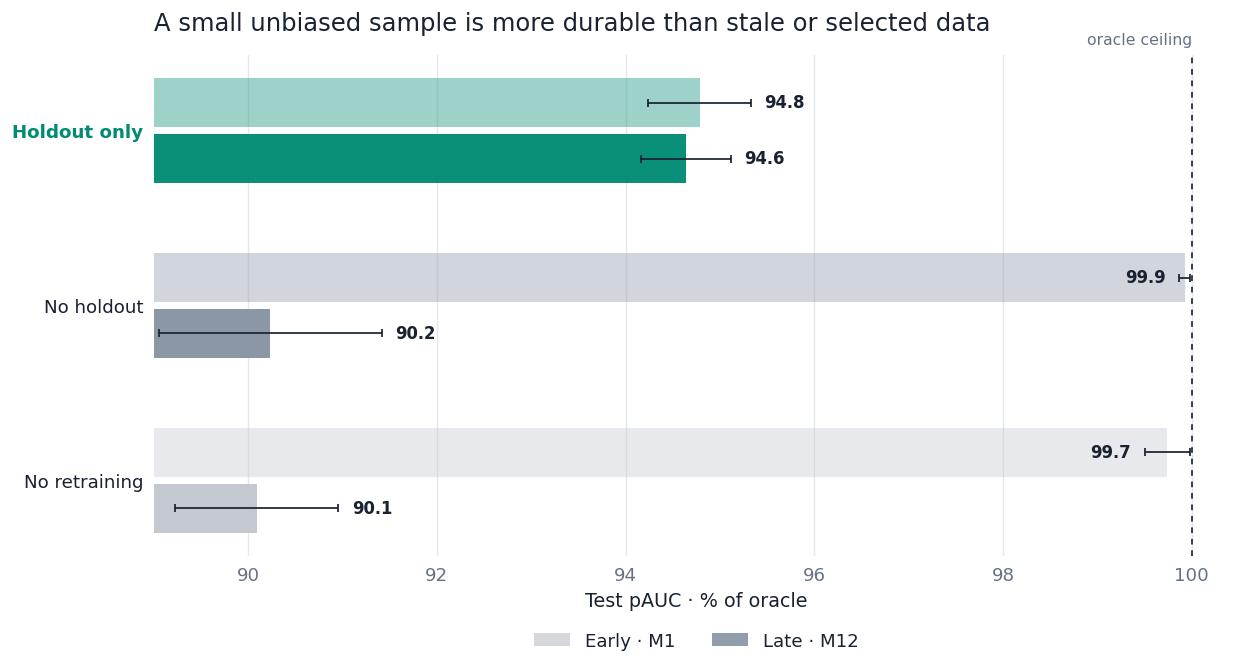

In [0]:
section3_methods = ["R1_holdout_only", "R2_unflagged_only", "R6_no_retrain"]
section3 = estimates(
    relative[(relative.scenario_id == "reference_drift") &
             relative.method.isin(section3_methods)],
    ["method", "period"], "pct_oracle")
section3_colors = {
    "R1_holdout_only": HOLDOUT_FOCUS,
    "R2_unflagged_only": "#8793A3",
    "R6_no_retrain": "#C2C7CE",
}

fig, ax = plt.subplots(figsize=(11.2, 5.2))
y = np.arange(len(section3_methods))
height = 0.32
for index, period in enumerate(["early", "late"]):
    positions = y + (index - 0.5) * height
    for row, method in enumerate(section3_methods):
        value = (section3[(section3.method == method) & (section3.period == period)]
                 .iloc[0])
        color = section3_colors[method]
        alpha = 0.38 if period == "early" else 0.96
        ax.barh(positions[row], value["mean"] - 89, left=89,
                xerr=value["half"], height=height * 0.88,
                color=color, alpha=alpha,
                error_kw={"ecolor": INK, "elinewidth": 1.0,
                          "capsize": 2.2, "capthick": 1.0}, zorder=3)
        if value["mean"] + value["half"] + 0.8 < 100.5:
            x, ha = value["mean"] + value["half"] + 0.14, "left"
        else:
            x, ha = value["mean"] - value["half"] - 0.14, "right"
        ax.text(x, positions[row], f"{value['mean']:.1f}", va="center", ha=ha,
                color=INK, fontsize=9.5, fontweight=600)
ax.set_yticks(y, [METHOD_LABELS[method] for method in section3_methods])
ax.invert_yaxis()
ax.set_xlim(89, 100.5)
ax.set_xlabel("Test pAUC · % of oracle")
ax.set_title("A small unbiased sample is more durable than stale or selected data", pad=14)
clean_axis(ax, "x", 2)
oracle_ceiling(ax, True)
ticks = ax.get_yticklabels()
ticks[0].set_color(HOLDOUT_FOCUS)
ticks[0].set_fontweight(700)
ax.legend(handles=period_legend(), loc="upper center",
          bbox_to_anchor=(0.5, -0.12), ncol=2)
save("fig03_holdout_durability.png")
plt.show()

## 4. Every method in the `strong regional signal + drift` scenario

The shared-scale figure supports direct early/late comparison. AIPW, IPW and dropping carry
the visual emphasis; the oracle appears only as the 100% ceiling.

sim-figures/fig04_methods_shared_scale.png


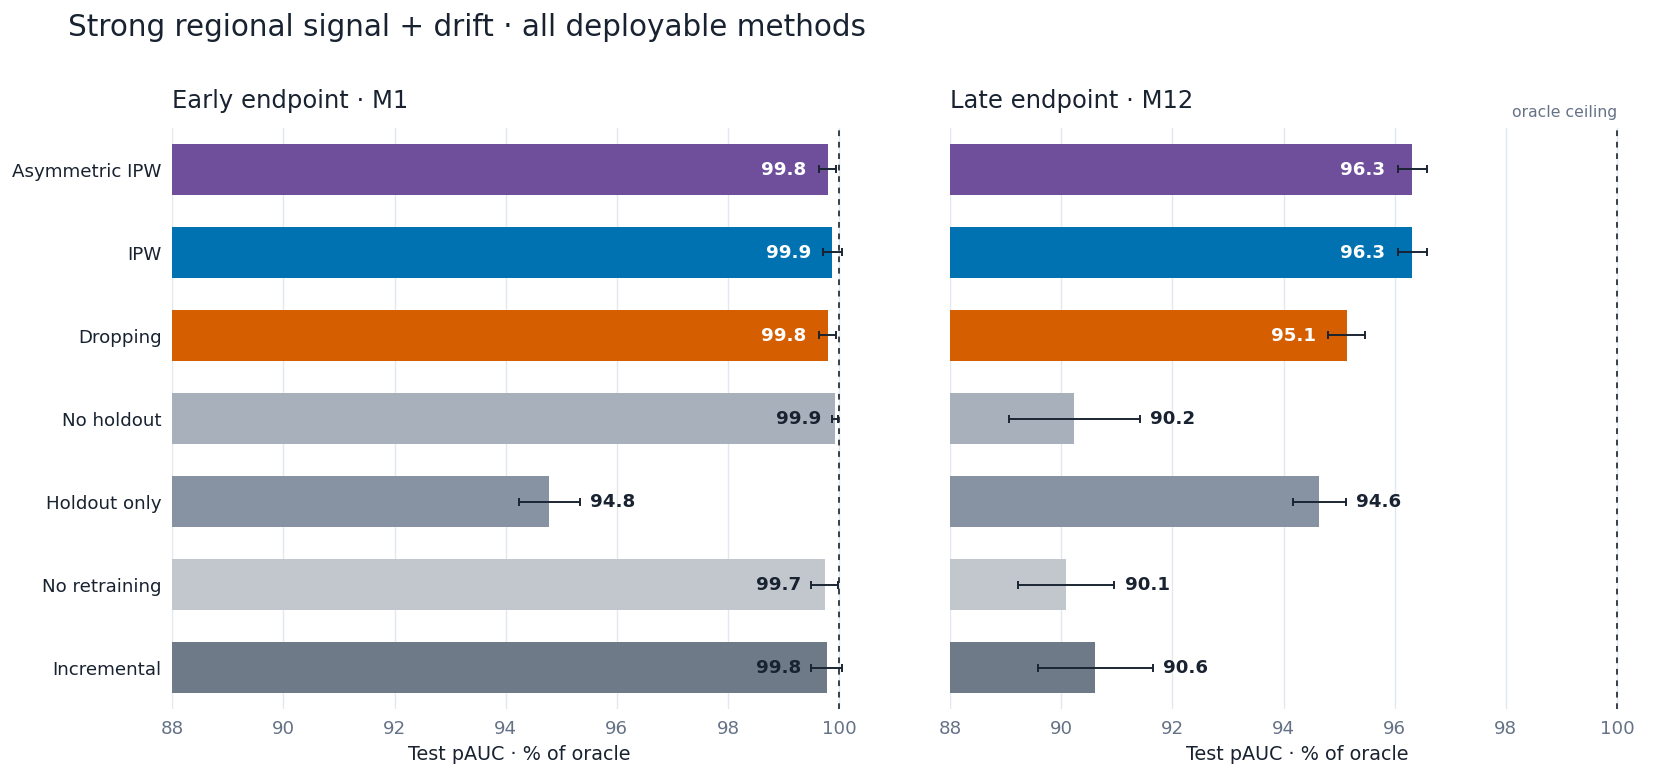

In [0]:
reference = all_estimates[(all_estimates.scenario_id == "reference_drift") &
                          all_estimates.method.isin(METHOD_ORDER)]
fig, axes = plt.subplots(1, 2, figsize=(15.2, 6.2), sharex=True, sharey=True)
for ax, period in zip(axes, ["early", "late"]):
    panel = reference[reference.period == period]
    month = 1 if period == "early" else 12
    method_bars(ax, panel, METHOD_ORDER, SCALE_MAIN,
                f"{period.capitalize()} endpoint · M{month}", ceiling_label=period == "late")
fig.suptitle("Strong regional signal + drift · all deployable methods",
             x=0.07, ha="left", y=1.01, fontsize=17, fontweight=500)
fig.subplots_adjust(top=0.86, wspace=0.12)
save("fig04_methods_shared_scale.png")
plt.show()

## 5. Robustness across all six scenarios

The six panels share the broad 84–100.5% scale. Early bars are translucent; late bars are
solid. A dedicated chart below summarizes each method's empirical performance floor.

sim-figures/fig05_all_scenarios.png


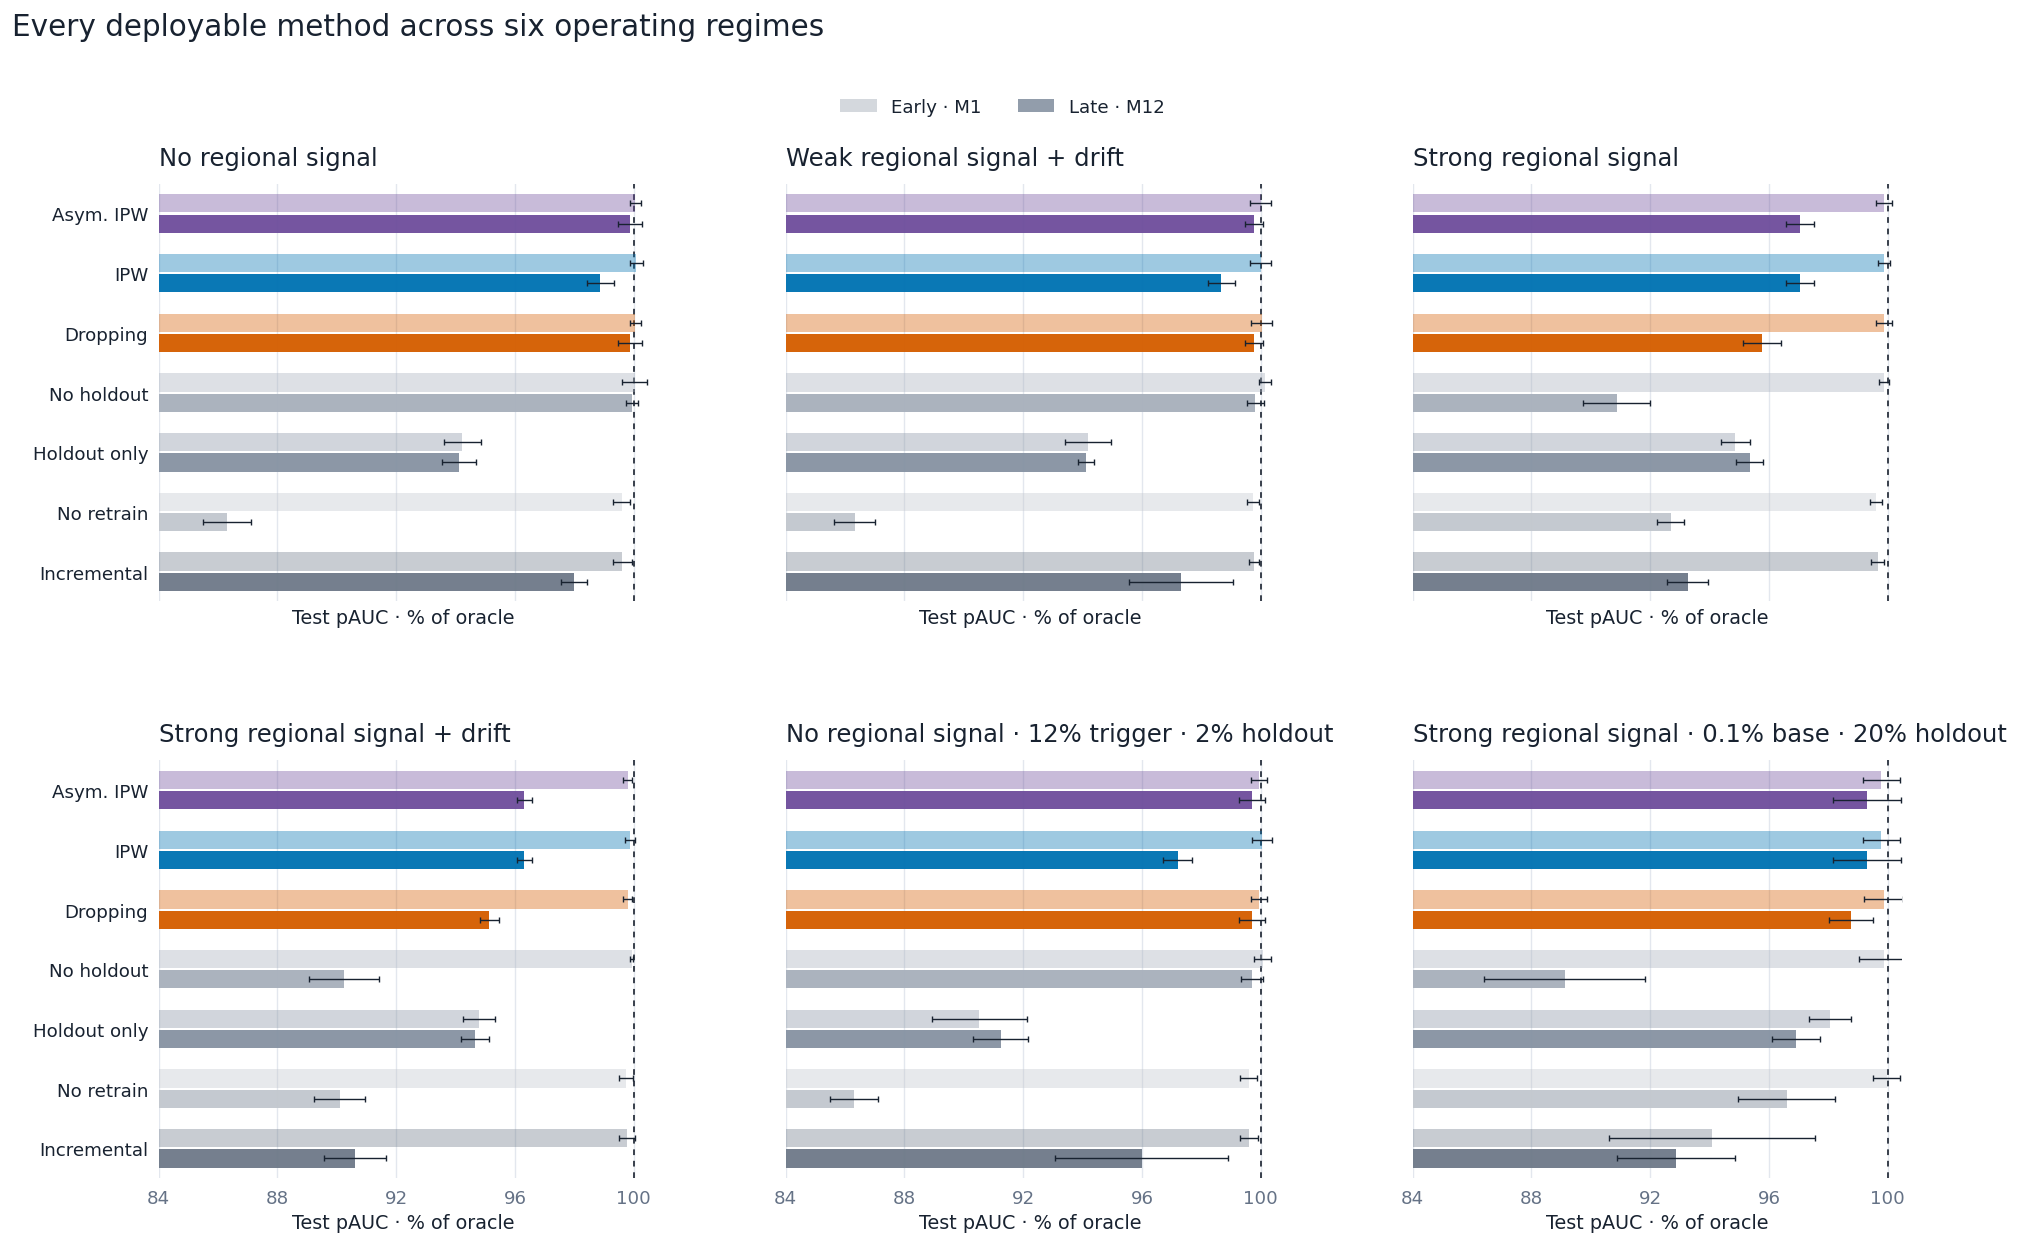

In [0]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10.2), sharex=True, sharey=True)
bar_height = 0.34
y = np.arange(len(METHOD_ORDER))
for ax, scenario_id in zip(axes.flat, SCENARIO_ORDER):
    cell = all_estimates[(all_estimates.scenario_id == scenario_id) &
                         all_estimates.method.isin(METHOD_ORDER)]
    for index, period in enumerate(["early", "late"]):
        values = cell[cell.period == period].set_index("method").reindex(METHOD_ORDER)
        positions = y + (index - 0.5) * bar_height
        for row, method in enumerate(METHOD_ORDER):
            value = values.loc[method, "mean"]
            half = values.loc[method, "half"]
            ax.barh(positions[row], value - SCALE_BROAD[0], left=SCALE_BROAD[0],
                    height=bar_height * 0.9, color=COLORS[method],
                    alpha=0.38 if period == "early" else 0.96,
                    xerr=half,
                    error_kw={"ecolor": INK, "elinewidth": 0.8,
                              "capsize": 1.8, "capthick": 0.8}, zorder=3)
    ax.set_yticks(y, [SHORT_LABELS[method] for method in METHOD_ORDER])
    ax.set_ylim(len(METHOD_ORDER) - 0.5, -0.5)
    ax.set_xlim(*SCALE_BROAD)
    ax.set_title(SCENARIO_LABELS[scenario_id], pad=11)
    ax.set_xlabel("Test pAUC · % of oracle")
    clean_axis(ax, "x", 4)
    oracle_ceiling(ax)
fig.legend(handles=period_legend(), loc="upper center", ncol=2,
           bbox_to_anchor=(0.5, 0.94))
fig.suptitle("Every deployable method across six operating regimes",
             x=0.06, ha="left", y=0.995, fontsize=17, fontweight=500)
fig.subplots_adjust(top=0.86, bottom=0.08, wspace=0.28, hspace=0.38)
save("fig05_all_scenarios.png")
plt.show()

### Average performance

These summaries average the six deliberately chosen scenarios. They describe robustness over
this panel, not the production prevalence of each regime. Oracle is excluded because every
value is already normalized to it; sampling error bars are omitted to keep the regime summary
distinct from the replicate-level figures above.

sim-figures/fig06_mean_performance_shared.png


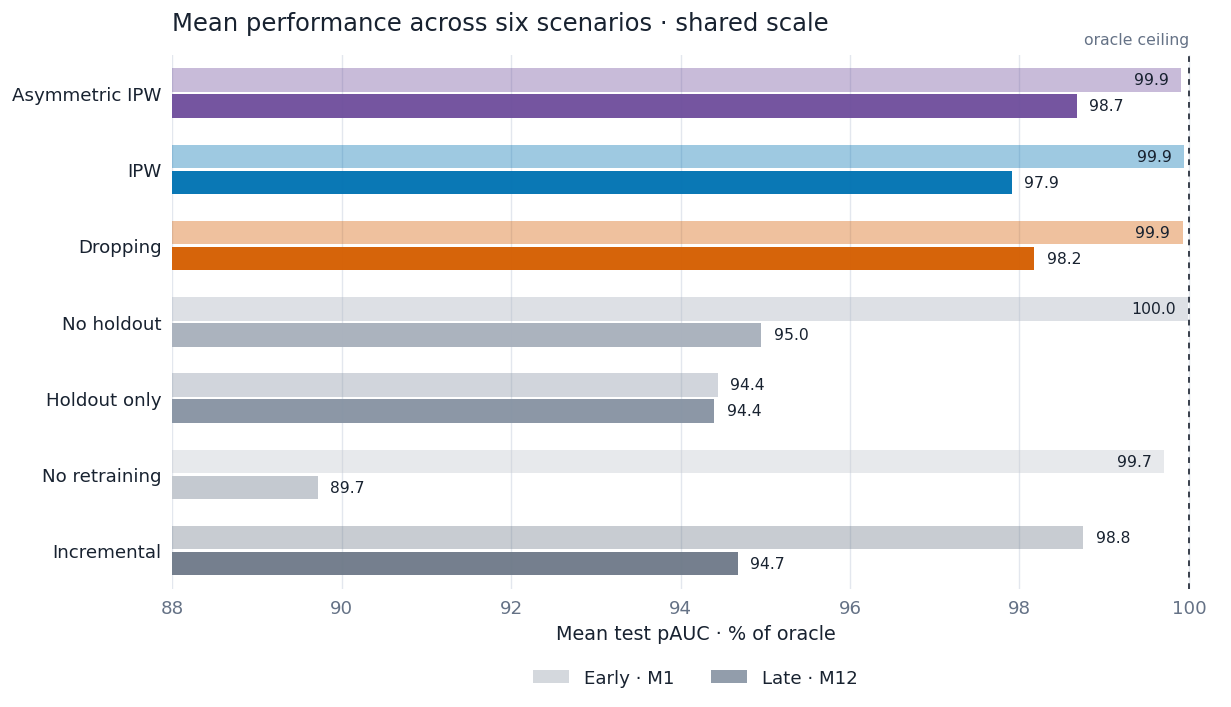

sim-figures/fig07_mean_performance_early.png


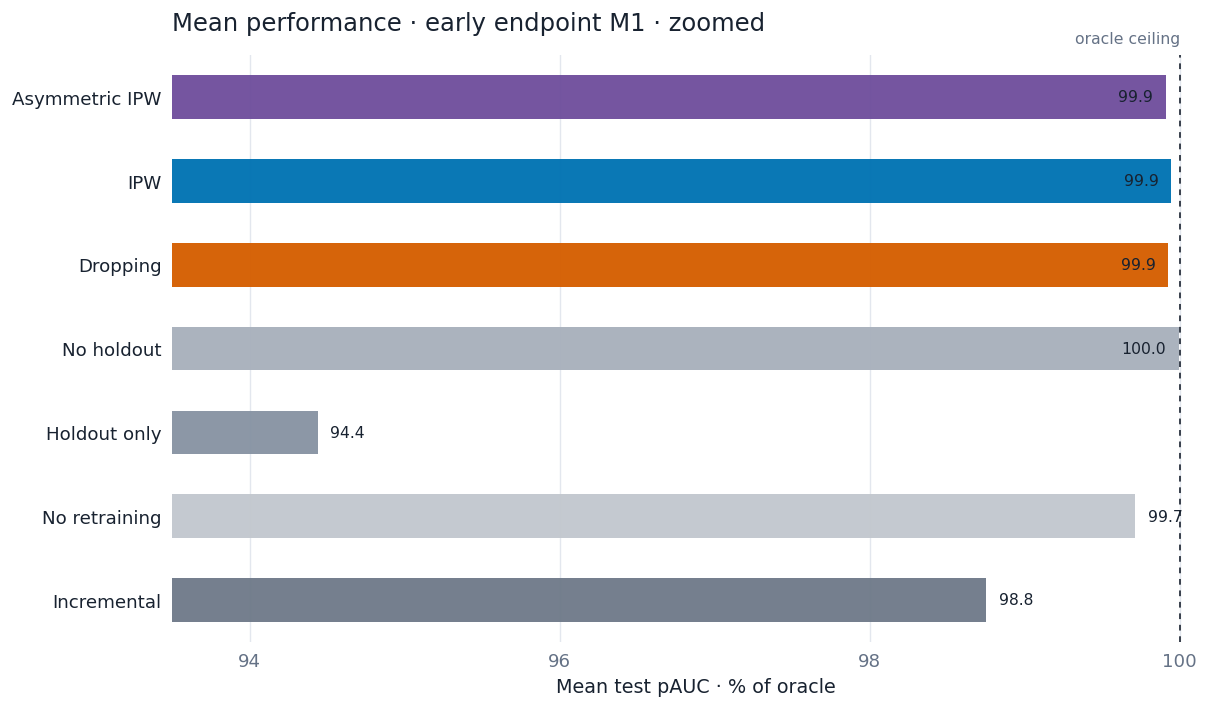

sim-figures/fig08_mean_performance_late.png


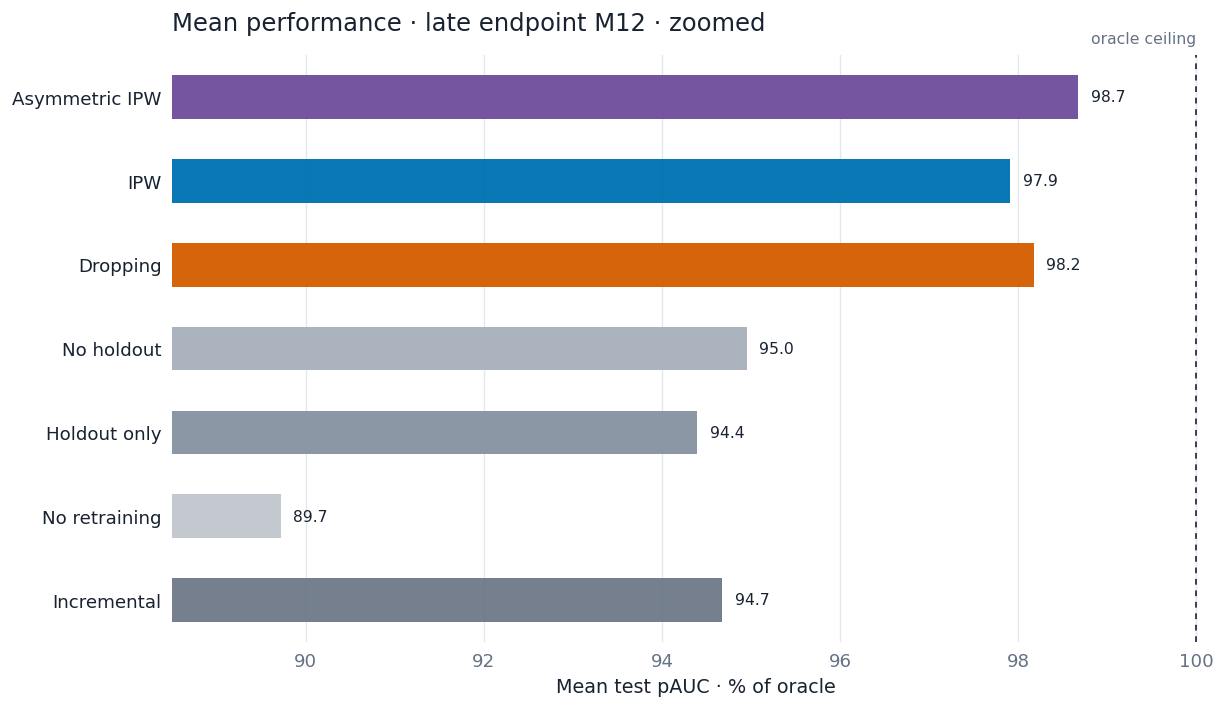

In [0]:
scenario_means = (all_estimates[all_estimates.method.isin(METHOD_ORDER)]
                  .groupby(["period", "method"], as_index=False)
                  .agg(mean=("mean", "mean")))


def aggregate_performance(periods, xlim, title, filename):
    fig, ax = plt.subplots(figsize=(10.8, 6.1))
    y = np.arange(len(METHOD_ORDER))
    height = 0.34 if len(periods) == 2 else 0.58
    for index, period in enumerate(periods):
        values = scenario_means[scenario_means.period == period].set_index(
            "method").reindex(METHOD_ORDER)
        positions = y + ((index - 0.5) * height if len(periods) == 2 else 0)
        for row, method in enumerate(METHOD_ORDER):
            value = values.loc[method, "mean"]
            alpha = 0.38 if len(periods) == 2 and period == "early" else 0.96
            ax.barh(positions[row], value - xlim[0], left=xlim[0], height=height * 0.9,
                    color=COLORS[method], alpha=alpha)
            label_bar(ax, value, positions[row], xlim)
    ax.set_yticks(y, [METHOD_LABELS[method] for method in METHOD_ORDER])
    ax.set_ylim(len(METHOD_ORDER) - 0.5, -0.5)
    ax.set_xlim(*xlim)
    ax.set_xlabel("Mean test pAUC · % of oracle")
    ax.set_title(title, pad=14)
    clean_axis(ax, "x", 2)
    oracle_ceiling(ax, True)
    if len(periods) == 2:
        ax.legend(handles=period_legend(), loc="upper center", ncol=2,
                  bbox_to_anchor=(0.5, -0.12))
        fig.subplots_adjust(bottom=0.18)
    save(filename)
    plt.show()


aggregate_performance(
    ["early", "late"], (88.0, 100.35),
    "Mean performance across six scenarios · shared scale",
    "fig06_mean_performance_shared.png",
)
aggregate_performance(
    ["early"], (93.5, 100.25),
    "Mean performance · early endpoint M1 · zoomed",
    "fig07_mean_performance_early.png",
)
aggregate_performance(
    ["late"], (88.5, 100.25),
    "Mean performance · late endpoint M12 · zoomed",
    "fig08_mean_performance_late.png",
)

### Average rank

Rank asks a different question: how often is a method near the top, regardless of the size of
the pAUC differences? Lower is better. The axis has its natural fixed range, so all three rank
exports use the same scale.

sim-figures/fig09_mean_rank_shared.png


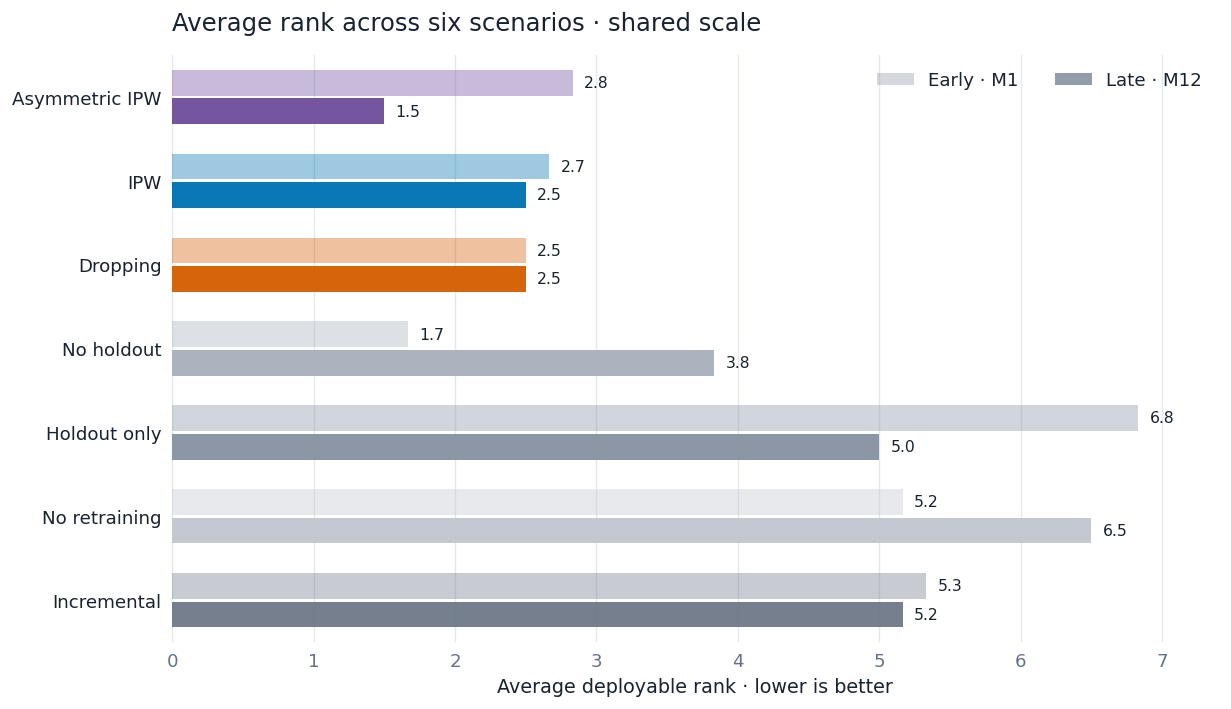

sim-figures/fig10_mean_rank_early.png


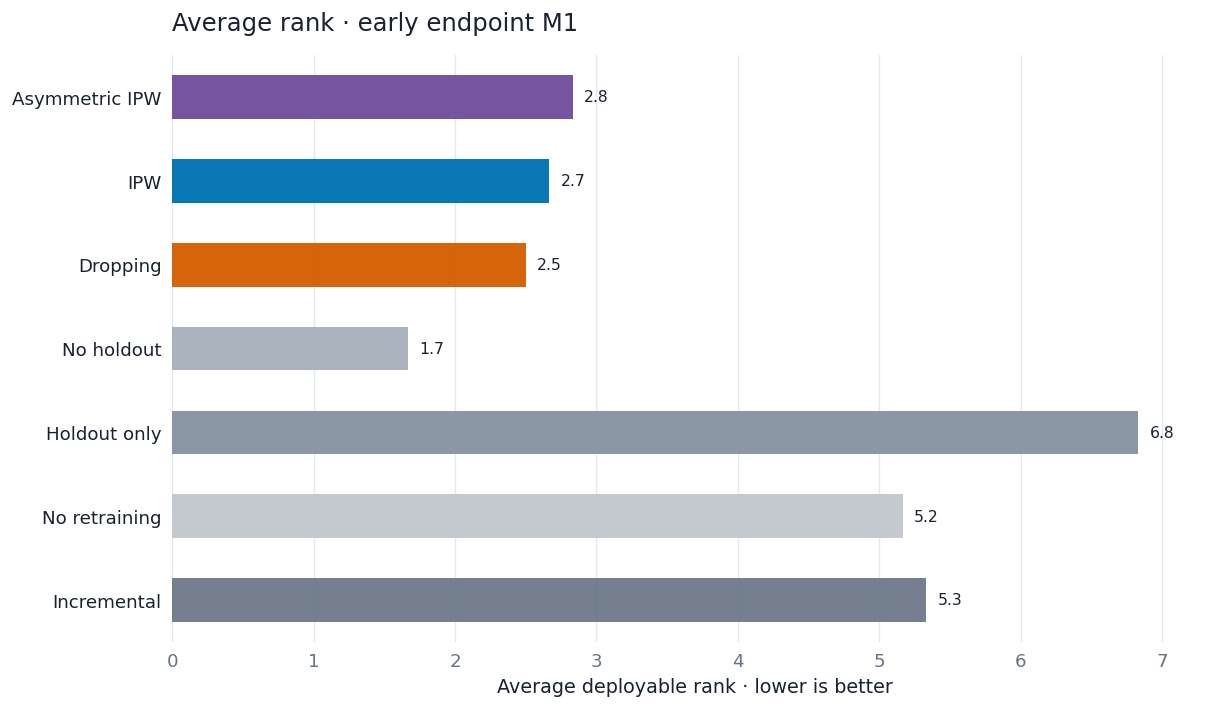

sim-figures/fig11_mean_rank_late.png


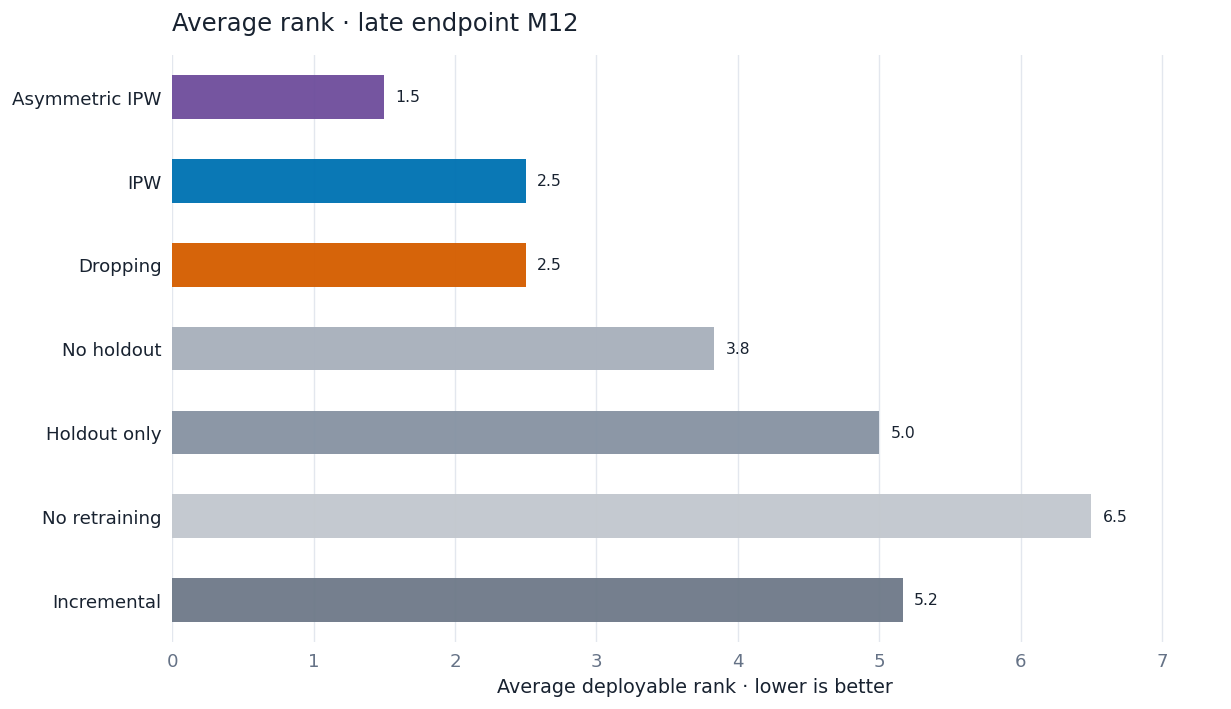

In [0]:
rank_summary = (methods[methods.method.isin(METHOD_ORDER)]
                .groupby(["period", "method"], as_index=False)
                .agg(mean=("rank", "mean")))


def aggregate_rank(periods, title, filename):
    fig, ax = plt.subplots(figsize=(10.8, 6.1))
    y = np.arange(len(METHOD_ORDER))
    height = 0.34 if len(periods) == 2 else 0.58
    for index, period in enumerate(periods):
        values = rank_summary[rank_summary.period == period].set_index(
            "method").reindex(METHOD_ORDER)
        positions = y + ((index - 0.5) * height if len(periods) == 2 else 0)
        for row, method in enumerate(METHOD_ORDER):
            value = values.loc[method, "mean"]
            alpha = 0.38 if len(periods) == 2 and period == "early" else 0.96
            ax.barh(positions[row], value, height=height * 0.9,
                    color=COLORS[method], alpha=alpha)
            ax.text(value + 0.08, positions[row], f"{value:.1f}", va="center",
                    color=INK, fontsize=9, fontweight=500)
    ax.set_yticks(y, [METHOD_LABELS[method] for method in METHOD_ORDER])
    ax.set_ylim(len(METHOD_ORDER) - 0.5, -0.5)
    ax.set_xlim(0, 7.4)
    ax.set_xlabel("Average deployable rank · lower is better")
    ax.set_title(title, pad=14)
    clean_axis(ax, "x", 1)
    if len(periods) == 2:
        ax.legend(handles=period_legend(), loc="upper right", ncol=2)
    save(filename)
    plt.show()


aggregate_rank(
    ["early", "late"], "Average rank across six scenarios · shared scale",
    "fig09_mean_rank_shared.png",
)
aggregate_rank(
    ["early"], "Average rank · early endpoint M1",
    "fig10_mean_rank_early.png",
)
aggregate_rank(
    ["late"], "Average rank · late endpoint M12",
    "fig11_mean_rank_late.png",
)

### Empirical performance floor

The floor is each method's worst scenario mean, reported separately by endpoint. This is an
empirical robustness bound—not a guarantee outside the simulated panel.

sim-figures/fig12_performance_floor.png


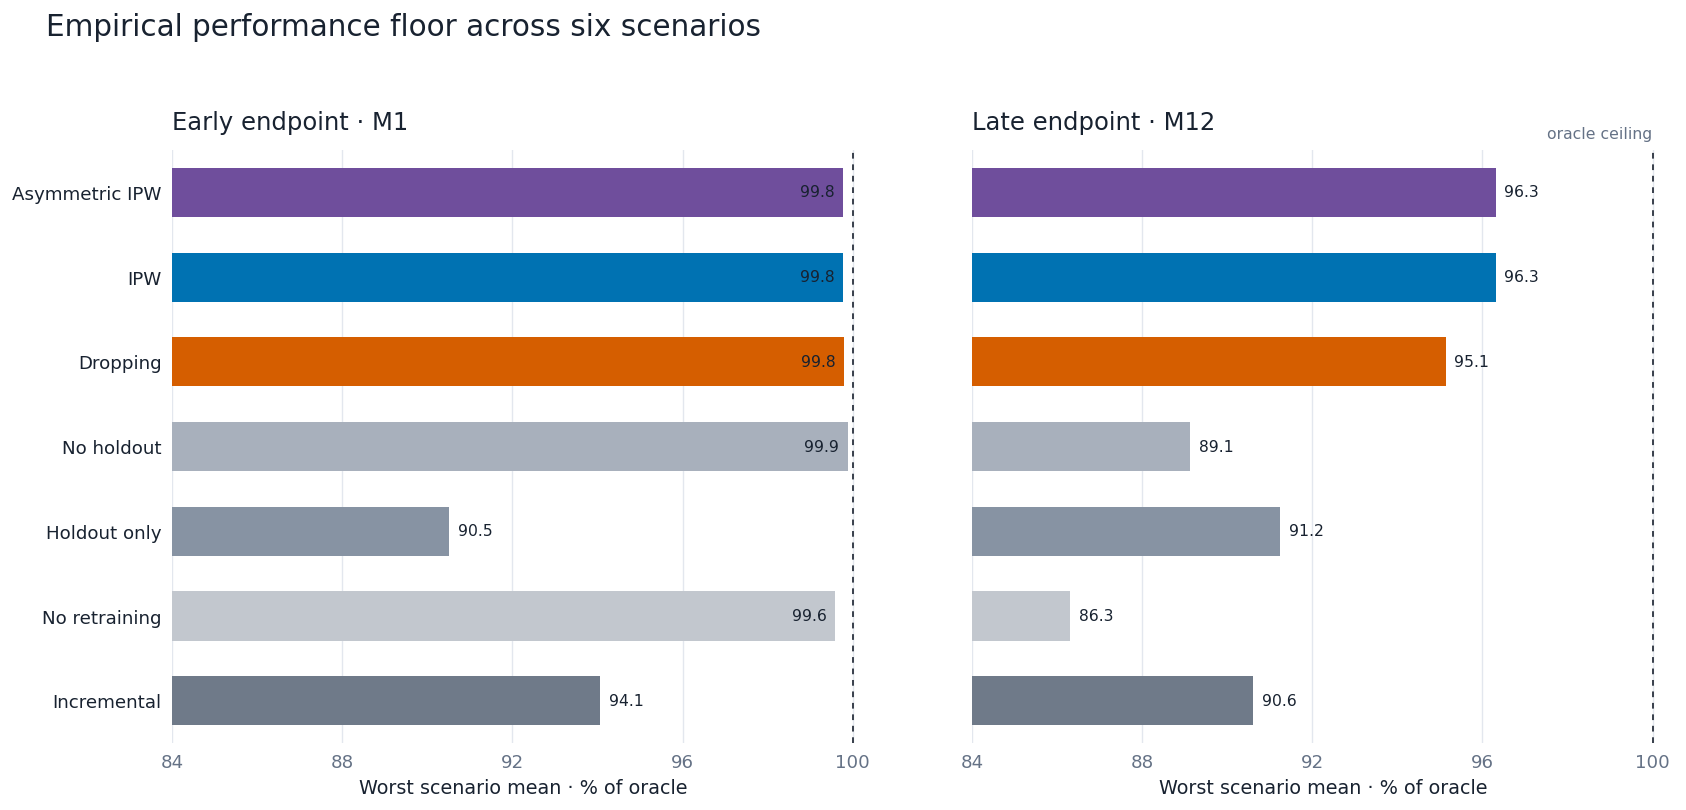

In [0]:
floor_index = (all_estimates[all_estimates.method.isin(METHOD_ORDER)]
               .groupby(["period", "method"])["mean"].idxmin())
floors = all_estimates.loc[floor_index].copy()

fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.5), sharex=True, sharey=True)
y = np.arange(len(METHOD_ORDER))
for ax, period in zip(axes, ["early", "late"]):
    cell = floors[floors.period == period].set_index("method").reindex(METHOD_ORDER)
    for row, method in enumerate(METHOD_ORDER):
        value = cell.loc[method, "mean"]
        ax.barh(row, value - SCALE_BROAD[0], left=SCALE_BROAD[0], height=0.58,
                color=COLORS[method], zorder=3)
        label_bar(ax, value, row, SCALE_BROAD, text=f"{value:.1f}", fontsize=9)
    ax.set_yticks(y, [METHOD_LABELS[method] for method in METHOD_ORDER])
    ax.set_ylim(len(METHOD_ORDER) - 0.5, -0.5)
    ax.set_xlim(*SCALE_BROAD)
    ax.set_xlabel("Worst scenario mean · % of oracle")
    ax.set_title(f"{period.capitalize()} endpoint · M{1 if period == 'early' else 12}", pad=12)
    clean_axis(ax, "x", 4)
    oracle_ceiling(ax, period == "late")
fig.suptitle("Empirical performance floor across six scenarios",
             x=0.06, ha="left", y=1.01, fontsize=17, fontweight=500)
fig.subplots_adjust(top=0.84, wspace=0.14)
save("fig12_performance_floor.png")
plt.show()

## 6. Dropping versus IPW: different information regimes favor each endpoint

Three scenarios clearly favor dropping and two clearly favor IPW under two-sided 95%
inference. The low-base/high-holdout scenario has an IPW lead in all five draws, but its
interval overlaps zero; it is shown as an IPW-favoring statistical tie.

sim-figures/fig13_dropping_wins.png


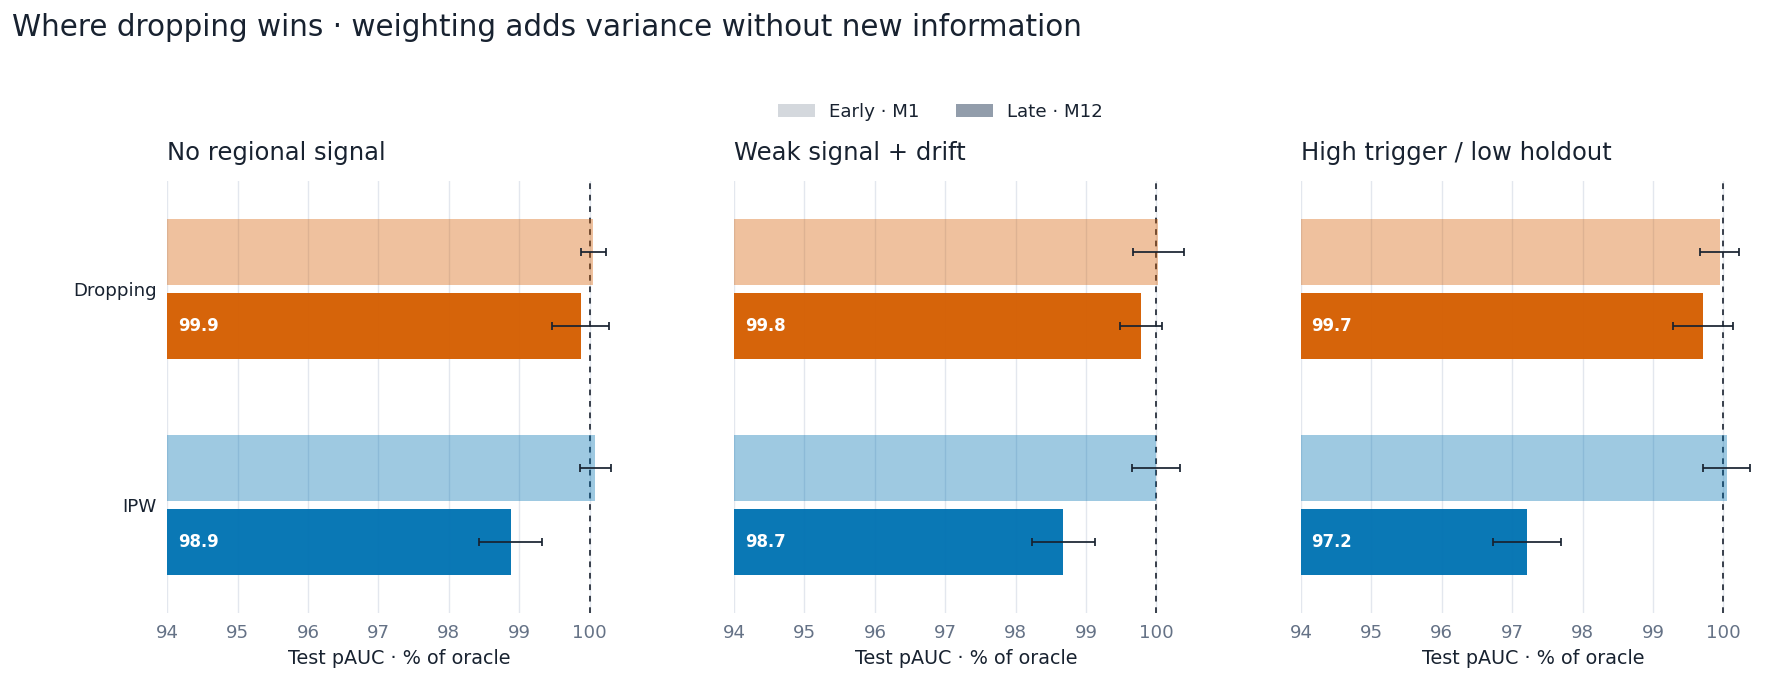

sim-figures/fig14_ipw_wins.png


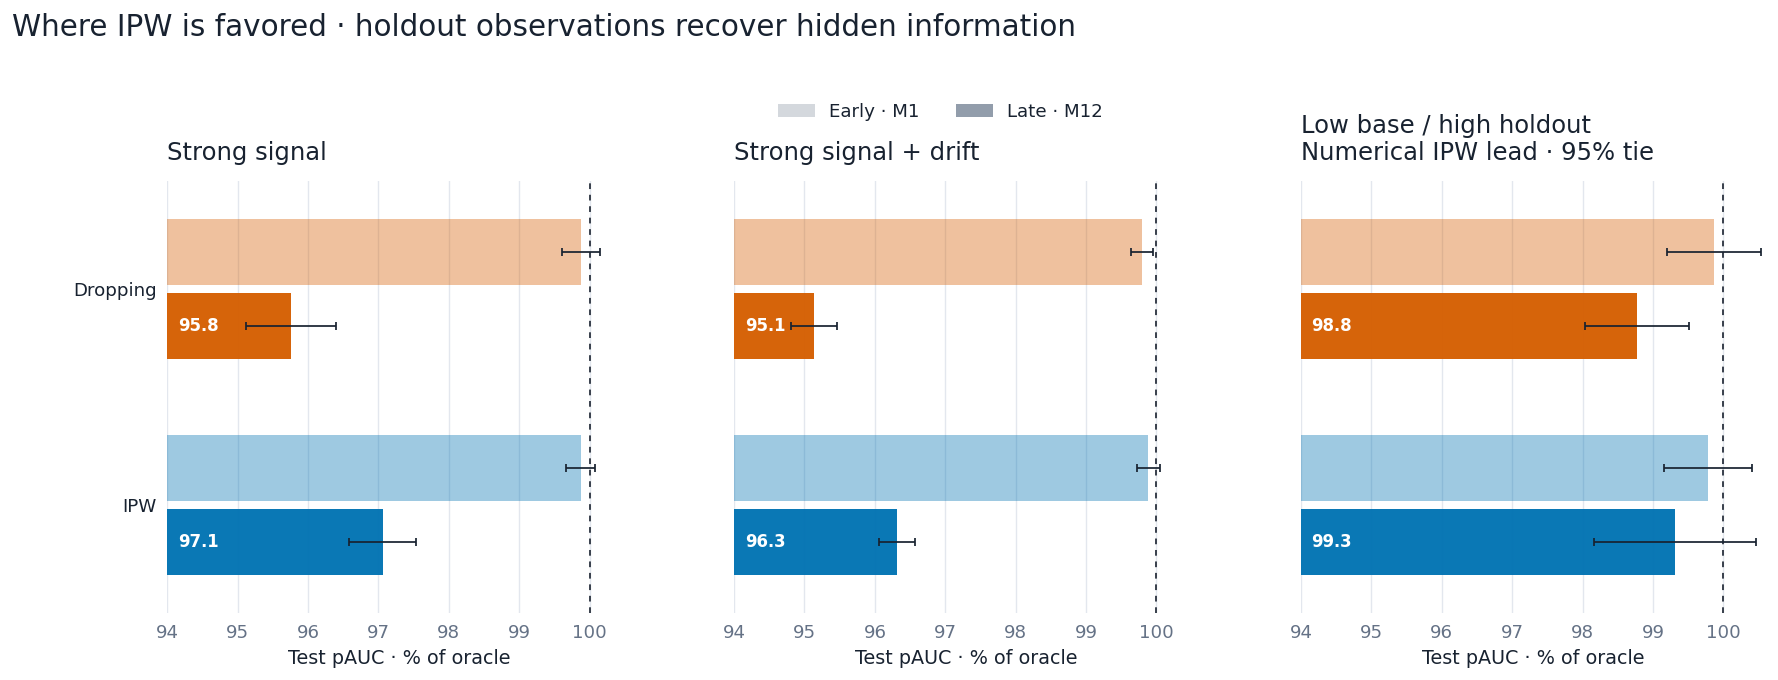

In [0]:
dropping_set = set(endpoints[(endpoints.period == "late") &
                             (endpoints.result == "dropping_wins")].scenario_id)
ipw_favored_set = set(endpoints[(endpoints.period == "late") &
                                (endpoints.ipw_minus_dropping > 0)].scenario_id)
dropping_scenarios = [item for item in SCENARIO_ORDER if item in dropping_set]
ipw_favored_scenarios = [item for item in SCENARIO_ORDER if item in ipw_favored_set]
late_endpoint_result = (endpoints[endpoints.period == "late"]
                        .set_index("scenario_id")["result"].to_dict())


def endpoint_panels(scenario_ids, method_ids, title, filename):
    fig, axes = plt.subplots(1, len(scenario_ids), figsize=(16.5, 5.4),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes)
    height = 0.34
    y = np.arange(len(method_ids))
    for ax, scenario_id in zip(axes, scenario_ids):
        cell = all_estimates[(all_estimates.scenario_id == scenario_id) &
                             all_estimates.method.isin(method_ids)]
        for index, period in enumerate(["early", "late"]):
            values = cell[cell.period == period].set_index("method").reindex(method_ids)
            positions = y + (index - 0.5) * height
            for row, method in enumerate(method_ids):
                value = values.loc[method, "mean"]
                half = values.loc[method, "half"]
                ax.barh(positions[row], value - SCALE_ENDPOINT[0],
                        left=SCALE_ENDPOINT[0], height=height * 0.9,
                        xerr=half, color=COLORS[method],
                        alpha=0.38 if period == "early" else 0.96,
                        error_kw={"ecolor": INK, "elinewidth": 1.0,
                                  "capsize": 2.2, "capthick": 1.0}, zorder=3)
                if period != "late":
                    continue
                if value - SCALE_ENDPOINT[0] >= 1.0:
                    x, ha, color = SCALE_ENDPOINT[0] + 0.15, "left", "white"
                else:
                    x, ha, color = value + 0.08, "left", INK
                ax.text(x, positions[row], f"{value:.1f}", va="center", ha=ha,
                        color=color, fontsize=9.5, fontweight=700, zorder=4)
        ax.set_yticks(y, [SHORT_LABELS[method] for method in method_ids])
        ax.set_ylim(len(method_ids) - 0.5, -0.5)
        ax.set_xlim(*SCALE_ENDPOINT)
        panel_title = SCENARIO_SHORT[scenario_id]
        if late_endpoint_result[scenario_id] == "tie":
            panel_title += "\nNumerical IPW lead · 95% tie"
        ax.set_title(panel_title, pad=12)
        ax.set_xlabel("Test pAUC · % of oracle")
        clean_axis(ax, "x", 1)
        oracle_ceiling(ax)
    fig.legend(handles=period_legend(), loc="upper center",
               bbox_to_anchor=(0.5, 0.89), ncol=2)
    fig.suptitle(title, x=0.05, ha="left", y=1.0, fontsize=17, fontweight=500)
    fig.subplots_adjust(top=0.75, wspace=0.22)
    save(filename)
    plt.show()


endpoint_panels(
    dropping_scenarios, ["R3_drop_unweighted", "R4_ipw_pure"],
    "Where dropping wins · weighting adds variance without new information",
    "fig13_dropping_wins.png",
)
endpoint_panels(
    ipw_favored_scenarios, ["R3_drop_unweighted", "R4_ipw_pure"],
    "Where IPW is favored · holdout observations recover hidden information",
    "fig14_ipw_wins.png",
)

## 7. Asymmetric IPW follows the winning endpoint

Dropping excels when the holdout is too small for stable weighting and censoring does not hide an essential outcome mechanism. IPW is favored when censoring hides a genuinely different risk relationship and the holdout is large enough to represent it reliably. Asymmetric IPW uses validation evidence to choose between those regimes.

This is a bias–variance trade-off. With a high trigger rate and a small holdout, IPW tries to use a small number of observed flagged transactions to represent a large censored population, assigning them extreme weights. If the censored cohort does not contain a distinct risk mechanism, this correction adds little useful information and can make the model overfit a few highly weighted examples; dropping is then more stable. With strong regional shift and a larger holdout, however, censoring removes observations that contain a genuinely different relationship between features and outcomes. Dropping becomes systematically biased, while IPW can recover that missing signal using a sufficiently representative holdout and moderate weights. Very low base rates still make this comparison noisy because each positive example matters more, explaining why the IPW advantage can be consistent across seeds while remaining only borderline statistically significant.

sim-figures/fig15_asymmetric_dropping_regimes.png


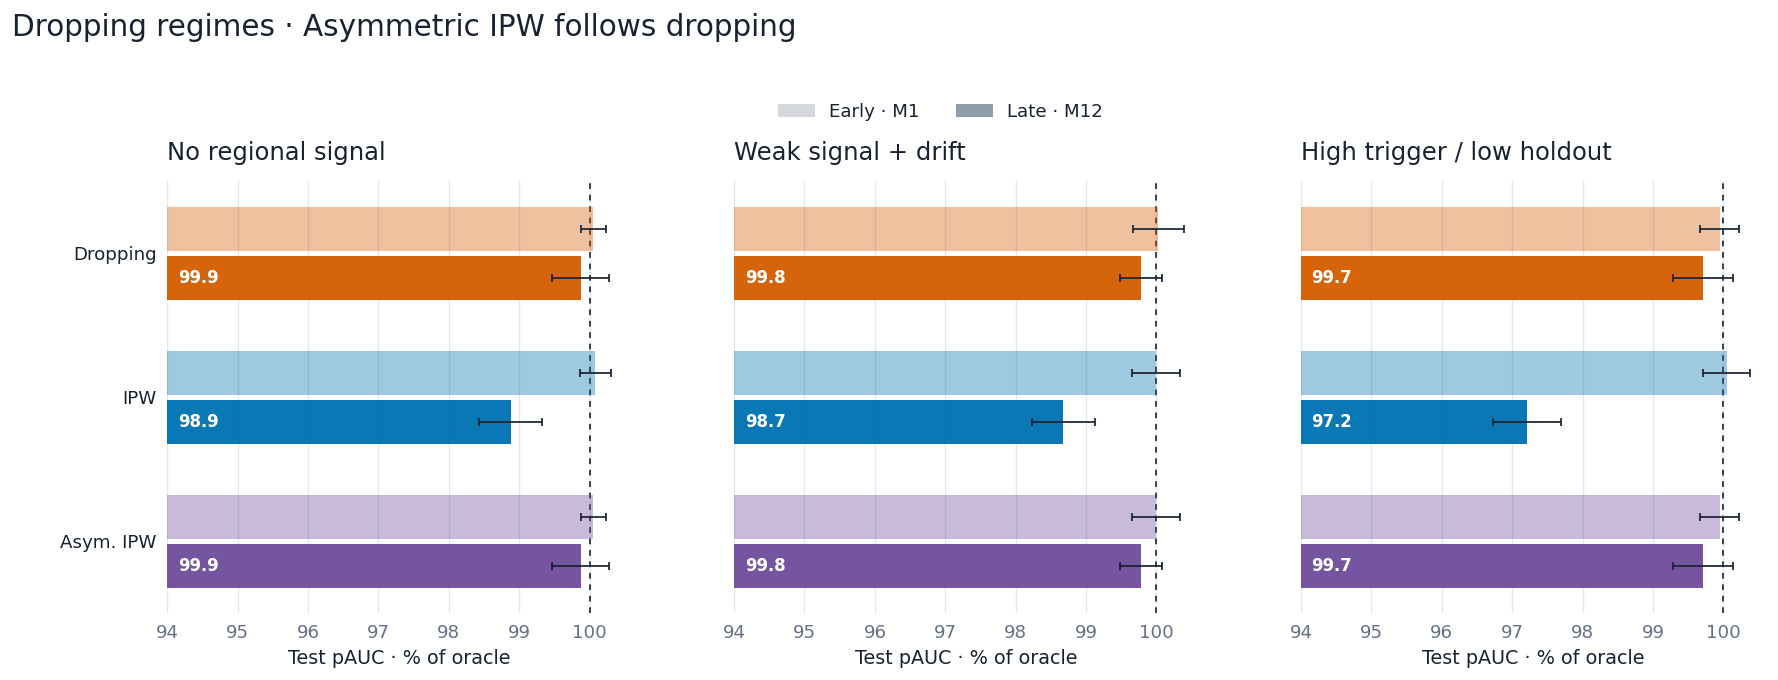

sim-figures/fig16_asymmetric_ipw_regimes.png


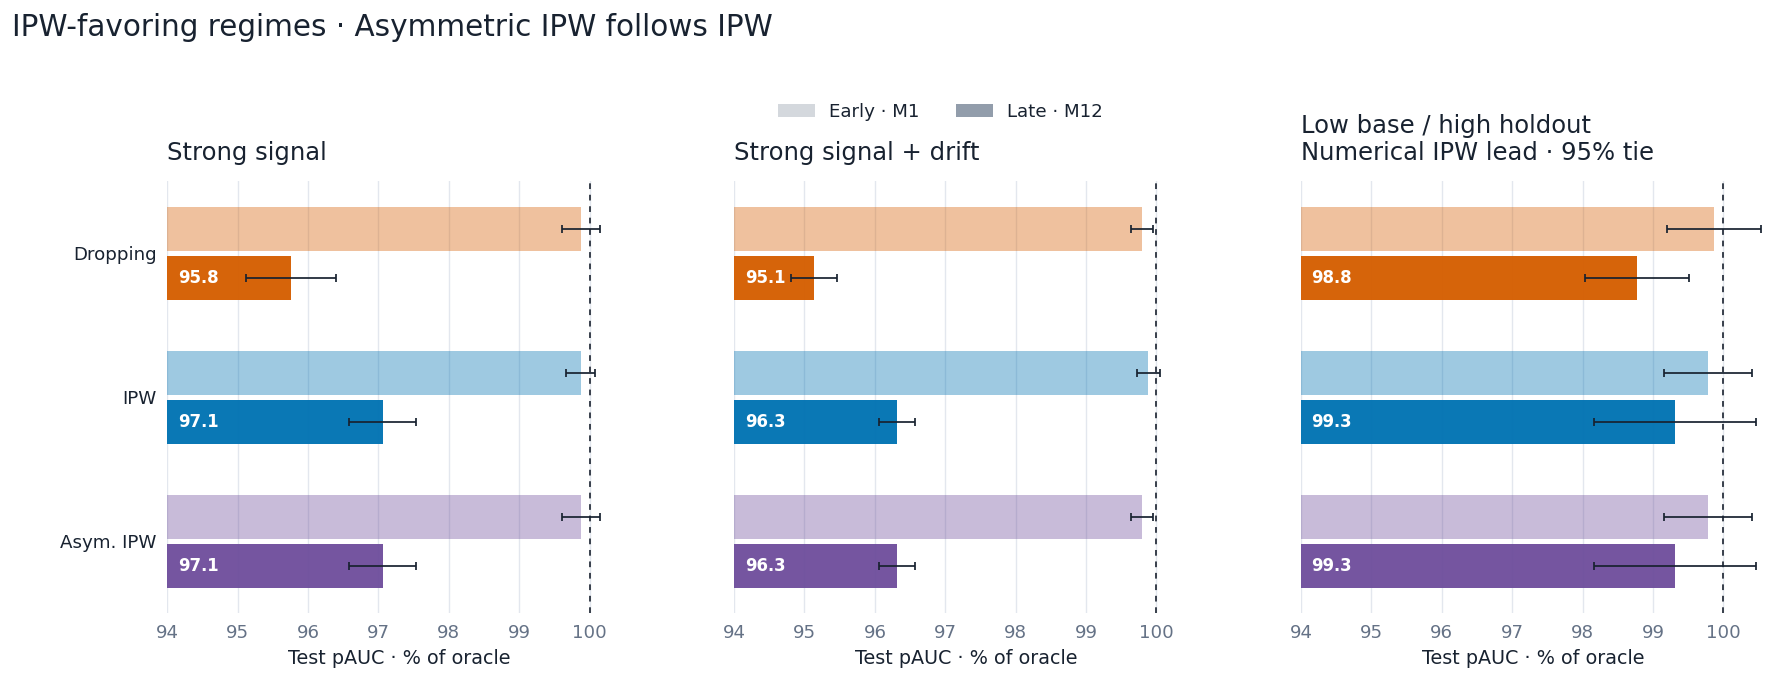

In [0]:
comparison_methods = ["R3_drop_unweighted", "R4_ipw_pure", "R5_asymmetric"]
endpoint_panels(
    dropping_scenarios, comparison_methods,
    "Dropping regimes · Asymmetric IPW follows dropping",
    "fig15_asymmetric_dropping_regimes.png",
)
endpoint_panels(
    ipw_favored_scenarios, comparison_methods,
    "IPW-favoring regimes · Asymmetric IPW follows IPW",
    "fig16_asymmetric_ipw_regimes.png",
)

Across all twelve scenario-period cells, Asymmetric IPW statistically ties the fixed better
endpoint. Validation selects the endpoint with the higher mean test score in all six late
scenarios; early differences are small enough that every endpoint comparison is a statistical
tie.

## Conclusions

1. Drift makes a fixed model stale, so retraining is necessary.
2. Policy-selected labels produce policy-selected metrics, so randomized holdout is necessary.
3. Holdout-only training is unbiased and durable, but its small sample gives up performance.
4. Dropping and IPW solve different information regimes; neither dominates universally.
5. Asymmetric IPW uses randomized-holdout validation to choose between them and provides the strongest late reliability across this scenario panel. It resolves the bias-variance tradeoff between the two options by favoring dropping when weighting is unstable and IPW when censoring hides essential risk information.

## Limitations

- Six synthetic regimes, one fixed DGP direction and five paired replicates per cell.
- The scenarios demonstrate mechanisms; they do not estimate real-life prevalence.
- Pooling simulation replicates approximates repeated temporal validation. Production tuning should use repeated time splits or cross-validation.
- pAUC measures ranking, not profit or downstream policy impact.
- Asymmetric IPW requires a randomized holdout; without it, neither unbiased validation nor inverse-probability correction is available.